<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/m3_c2_scaling_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📐 Module 3 — Class 2: Make Numbers Comparable (Scaling)

**Lesson:** [bepro-aiml.github.io/aiml-platform/#/module/3/class/2](https://bepro-aiml.github.io/aiml-platform/#/module/3/class/2)

---

## 📖 Today's story

Yesterday you **cleaned** the customer data. ✅

Today the boss asks: *"OK, train the model now!"*

But there is one more problem hiding in the data...

Look at our customers. We have:
- `tenure` → numbers from **0 to 72** (months)
- `MonthlyCharges` → numbers from **18 to 118** (dollars)
- `TotalCharges` → numbers from **0 to 8,500** (dollars)

All are numbers. **But the sizes are very different!**

The model will think: *"TotalCharges is most important because it's the biggest!"* ❌

**That is wrong.** A 1-month tenure change is NOT less important than a 1-dollar TotalCharges change. They just use different scales.

**Today we make all numbers fair to compare.**

---

## 💡 What is "scaling"?

**Scaling = making different numbers fit in a similar range.**

Example:
- BEFORE: tenure = 36 months, charges = 4,500 dollars (very different sizes)
- AFTER:  tenure = 0.5, charges = 0.5 (now they are equal in size)

We do not change WHAT the data means. We only change the **size of the numbers**.

---

## 🎯 Today's plan

1. **Setup** — get our cleaned data
2. **See the problem** — why different sizes break the model
3. **Tool 1: StandardScaler** — make mean = 0, spread = 1
4. **Tool 2: MinMaxScaler** — squeeze to [0, 1]
5. **Tool 3: RobustScaler** — best when outliers exist
6. **The BIG rule** — fit on train data ONLY (or you cheat!)
7. **Compare** — which scaler wins on a real model?
8. **Save** scaled data for Class 3

## 🤖 How to run

Click a code cell → press **Shift + Enter**.

👉 Each cell prints **what to look at** AND **why it matters**. Read the output text!

---

# 🧰 First — What is scikit-learn?

Today is the **first time** we use a new tool: **scikit-learn** (people say *"sklearn"*).

Before we use it, let's understand what it is. This will take ~20 minutes but it will make EVERY future class easier.

## 📦 The toolbox analogy

Imagine a **carpenter**. They have a toolbox:
- 🔨 hammer — for nails
- 🪛 screwdriver — for screws
- 📏 ruler — for measuring
- 🪚 saw — for cutting

Each tool does ONE job. Carpenter picks the right tool for the right job.

**scikit-learn is the same thing — but for machine learning.**

It's a toolbox with hundreds of tools:
- 📐 tools to **prepare data** (scaling, cleaning numbers)
- 🤖 tools to **train models** (KNN, Random Forest, Linear Regression)
- 📊 tools to **check models** (accuracy, precision)
- 🎯 tools to **find best settings** (auto-tuning)

We pick the right tool for our job.

## 💡 Why do we need sklearn? Why not write code ourselves?

If we wrote everything ourselves:
- ❌ Hundreds of lines of math for ONE model
- ❌ Slow (Python is not fast for math)
- ❌ Bugs! Math errors are hard to find

With sklearn:
- ✅ 2-3 lines per model
- ✅ Very fast (the heavy math is written in a low-level computer language under the hood, so it runs at top speed — you don't have to think about it)
- ✅ Tested by millions of people — almost no bugs

**Almost EVERY ML project in the world uses sklearn. It is the standard.**

## 🌍 Real-world fact

If you go to LinkedIn or a job interview for an ML role:
- They will ask: *"Do you know sklearn?"*
- Not asking: *"Can you write KNN from scratch?"*

So learning sklearn = learning the job skill.

---

## 🎯 The 4 jobs sklearn does

Every ML project follows the same 4 steps. sklearn has tools for all of them.

| # | Job | What it means | Example tool |
| --- | --- | --- | --- |
| 1 | **Prepare data** | Make data ready for the model | `StandardScaler` |
| 2 | **Split data** | Train + test parts | `train_test_split` |
| 3 | **Train a model** | Teach the model to predict | `KNeighborsClassifier` |
| 4 | **Check the model** | Measure how good it is | `accuracy_score` |

We will use ALL 4 today!

## 💡 The MAGIC of sklearn — every tool works the same way

The carpenter needs to learn each tool separately (hammer is different from saw).

**But sklearn is different.** Every tool follows ONE of two simple patterns. Once you learn the pattern, ALL tools become easy.

Let me explain the 2 patterns 👇

---

## 🛠️ Pattern 1: Preprocessor tools (`fit` then `transform`)

These are tools that **prepare** the data. Like StandardScaler, MinMaxScaler, OneHotEncoder.

They follow 2 steps:

### Step 1: `fit()` — LEARN from the data

The tool looks at the data and **memorizes important numbers**.

For StandardScaler, it memorizes:
- The **mean** (average)
- The **std** (spread)

It does NOT change the data yet. Just learns.

```python
scaler = StandardScaler()
scaler.fit(X_train)   # ← learns mean and std from X_train
```

### Step 2: `transform()` — APPLY what was learned

Now use the memorized numbers to actually change the data.

```python
X_scaled = scaler.transform(X_train)   # ← uses the memorized mean/std to scale
```

### 🎁 Shortcut: `fit_transform()` does BOTH at once

If you want to fit and transform on the same data:

```python
X_scaled = scaler.fit_transform(X_train)   # ← fit AND transform in one line
```

**WARNING:** Use `fit_transform` ONLY on training data. Use `transform` (no fit) on test data!

### 🍞 Real-life analogy

Imagine making **bread**:
- `fit()` = read the recipe (learn the rules)
- `transform()` = make the bread (apply the rules)
- `fit_transform()` = read the recipe and make the bread together

You read the recipe ONCE. Then you can make many breads. Same with sklearn — `fit` once on training data, then `transform` many times on new data.

---

## 🤖 Pattern 2: Model tools (`fit` then `predict` then `score`)

These are tools that **predict** something. Like KNN, Random Forest, Logistic Regression.

They follow 3 steps:

### Step 1: `fit()` — LEARN from training data

The model looks at examples and learns patterns.

```python
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)   # ← learns from train data + correct answers
```

Notice: this `fit` takes **two** things:
- `X_train` = the features (numbers about each customer)
- `y_train` = the correct answer for each customer (did they leave? Yes/No)

### Step 2: `predict()` — GUESS the answer for new data

```python
predictions = model.predict(X_test)   # ← guesses Yes/No for each test customer
```

### Step 3: `score()` — CHECK how often the model is right

```python
accuracy = model.score(X_test, y_test)   # ← compares guesses with real answers
```

### 🎓 Real-life analogy

Imagine teaching a child:
- `fit()` = show them many examples ("This is a cat. This is a dog.")
- `predict()` = ask them about new pictures ("What is this?")
- `score()` = check how many they got right (8 out of 10 = 80%)

**That's it!** Two patterns. Every sklearn tool uses one of them.

---

## 🎬 Hello sklearn — let's actually USE it

Before we touch our customer data, let's run a **tiny example** so you SEE the patterns work.

The next cell:
1. Takes 5 simple numbers: `[10, 20, 30, 40, 50]`
2. Uses StandardScaler to scale them
3. Shows what changed

This is the simplest possible sklearn example. After this, the rest of the lesson will feel easy.

In [1]:
# 🎬 HELLO SKLEARN — tiniest possible example

# Step 1: import the tool
from sklearn.preprocessing import StandardScaler

# Step 2: get our tiny data — 5 simple numbers
# (Note the [[ ]] — sklearn always wants a 2D table, not 1D)
data = [[10], [20], [30], [40], [50]]

print('🔢 BEFORE scaling:')
print(f'   Numbers: {[row[0] for row in data]}')
print(f'   Mean   : 30.0')
print(f'   Range  : 10 to 50')
print()

# Step 3: create the tool
scaler = StandardScaler()

# Step 4: fit + transform (the magic 1-liner!)
scaled = scaler.fit_transform(data)

print('✅ AFTER scaling:')
print(f'   Numbers: {[round(row[0], 2) for row in scaled]}')
print(f'   Mean   : {scaled.mean():.2f}  ← became 0!')
print(f'   Std    : {scaled.std():.2f}  ← became 1!')
print()
print('━' * 50)
print('💡 What happened?')
print('   • fit() learned: mean=30, std=14.14')
print('   • transform() applied: new = (old - 30) / 14.14')
print('   • Result: mean=0, std=1 (the StandardScaler magic!)')
print('━' * 50)

🔢 BEFORE scaling:
   Numbers: [10, 20, 30, 40, 50]
   Mean   : 30.0
   Range  : 10 to 50

✅ AFTER scaling:
   Numbers: [np.float64(-1.41), np.float64(-0.71), np.float64(0.0), np.float64(0.71), np.float64(1.41)]
   Mean   : 0.00  ← became 0!
   Std    : 1.00  ← became 1!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
💡 What happened?
   • fit() learned: mean=30, std=14.14
   • transform() applied: new = (old - 30) / 14.14
   • Result: mean=0, std=1 (the StandardScaler magic!)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---

## 📦 What we'll import today (and why)

Now you know what sklearn is. Below are the 4 tools we'll import for today's lesson:

| Import | What it does | Pattern |
| --- | --- | --- |
| `StandardScaler` | Scale: mean=0, std=1 | Preprocessor (fit + transform) |
| `MinMaxScaler` | Scale: range [0, 1] | Preprocessor (fit + transform) |
| `RobustScaler` | Scale: uses median + IQR | Preprocessor (fit + transform) |
| `train_test_split` | Split data into 2 parts | Function (not a tool to fit) |
| `KNeighborsClassifier` | Predict using K nearest customers | Model (fit + predict + score) |
| `accuracy_score` | Measure: % of correct guesses | Function (compare 2 lists) |

You'll see all 6 today. **You already used StandardScaler above** — congratulations, you're using sklearn!

🎯 **Now we're ready.** Let's start the real lesson with our customer data 👇

---
## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

# We will use sklearn — the most popular ML library in Python.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print('✅ Tools ready! We are using:')
print('   • pandas, numpy, matplotlib (you know these from Module 2)')
print('   • sklearn = scikit-learn (the BIG ML library)')

✅ Tools ready! We are using:
   • pandas, numpy, matplotlib (you know these from Module 2)
   • sklearn = scikit-learn (the BIG ML library)


---

## 📖 Quick reference — words and code idioms you'll see today

Before we dive in, here's a tiny reference card. Don't memorize anything. Just **scroll back here** when something looks weird in the code below.

### 🧠 5 ML words you'll see everywhere

| Word | What it means | Example in our data |
| --- | --- | --- |
| **feature** | An input column the model uses to predict something | `tenure`, `MonthlyCharges` |
| **target** | The column we want to predict (the answer) | `Churn` (did the customer leave? Yes/No) |
| **X** (uppercase) | All features together → a 2D **table** | `df[['tenure','MonthlyCharges','TotalCharges']]` |
| **y** (lowercase) | The target column → a 1D **list** | `df['Churn']` |
| **production** | The model running for real on real customers (after class!) | Your code on the company website |

> 💡 **Memory trick:** *"X is what we **know** about a customer. y is what we **want to know**."*
>
> Example: I know Ali's tenure (X). I want to know: will he leave? (y).

### 🐍 Python tricks you'll see in code below

| What you'll see | What it does (in plain English) |
| --- | --- |
| `pd.to_numeric(..., errors='coerce')` | Convert text to numbers. If it fails on a row → put NaN (empty) instead of crashing. |
| `.astype(int)` | Convert column to whole numbers (0, 1, 2 ...) |
| `.describe()` | Pandas: show summary stats (mean, std, min, max) for every column |
| `random_state=42` | Lock the randomness — you get the **SAME split** every run, so results are reproducible |
| `joblib.dump(thing, 'file')` | Save any Python object to disk so you can re-use it tomorrow |
| `warnings.filterwarnings('ignore')` | Hide ugly orange warning messages — keeps the notebook clean |
| `[[10],[20],[30]]` (double brackets) | A 2D list. **sklearn always wants 2D**, never 1D — that's why you see `[[ ]]` a lot |

🎯 You don't need to remember all of these now. They will appear again — and again — and you'll get used to them naturally. This list is just a **safety net** for when you get stuck.

---
## Step 1: Get our cleaned data 📥

We need the file we cleaned in Class 1. Just to be safe, we re-do the C1 fixes here so you can run this notebook from scratch.

In [3]:
# Load Telco data and apply Class 1 fixes (just 2 lines)
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Fix 1: TotalCharges from text to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Fix 2: collapse 'No internet/phone service' to 'No'
for c in ['OnlineSecurity','OnlineBackup','DeviceProtection',
          'TechSupport','StreamingTV','StreamingMovies']:
    df[c] = df[c].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print(f'✅ Loaded {len(df)} customers from Telco. Ready to scale!')

✅ Loaded 7043 customers from Telco. Ready to scale!


---
## Step 2: See the problem 👀

> **Why do we need scaling?**

Let's look at 3 number columns and see how different their sizes are.

In [4]:
# Show min/max of 3 number columns
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('🔍 Range of values for each column:')
print()
for c in cols:
    print(f'  {c:18s} : min = {df[c].min():>8.1f}  max = {df[c].max():>8.1f}')
print()
print('━' * 50)
print('🚨 PROBLEM: The 3 columns are on VERY different scales!')
print()
print('   tenure        goes from 0 to ~72       (small numbers)')
print('   MonthlyCharges goes from ~18 to ~118    (medium numbers)')
print('   TotalCharges  goes from 0 to ~8,500    (BIG numbers)')
print()
print('💡 The model will think TotalCharges is the "most important"')
print('   feature — just because the numbers are bigger.')
print('   This is WRONG. Big number ≠ more important.')
print('━' * 50)

🔍 Range of values for each column:

  tenure             : min =      0.0  max =     72.0
  MonthlyCharges     : min =     18.2  max =    118.8
  TotalCharges       : min =      0.0  max =   8684.8

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 PROBLEM: The 3 columns are on VERY different scales!

   tenure        goes from 0 to ~72       (small numbers)
   MonthlyCharges goes from ~18 to ~118    (medium numbers)
   TotalCharges  goes from 0 to ~8,500    (BIG numbers)

💡 The model will think TotalCharges is the "most important"
   feature — just because the numbers are bigger.
   This is WRONG. Big number ≠ more important.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 🤔 Why does this happen?

Many ML models use **distance** to compare customers.

**Distance** = how far apart 2 customers are. Like measuring 2 cities on a map.

Imagine 2 customers:
- Ali: tenure = 10, MonthlyCharges = 30, TotalCharges = 300
- Zara: tenure = 12, MonthlyCharges = 32, TotalCharges = 400

Difference:
- tenure: 2 (small)
- MonthlyCharges: 2 (small)
- **TotalCharges: 100 (BIG!)**

The model sees: *"Ali and Zara are very different — TotalCharges differs by 100!"*

But really, all 3 differences mean the same thing! TotalCharges just LOOKS bigger because of the scale.

👉 **Scaling fixes this.** It makes a 2-month tenure difference equally important to a 200-dollar TotalCharges difference.

### Which models care about scaling?

| Model type | Cares? | Why |
| --- | --- | --- |
| 📏 **K-NN, K-Means** | ✅ YES | They use distance |
| 📈 **Linear / Logistic Regression** | ✅ YES | Math works better with similar sizes |
| 🧠 **Neural networks** | ✅ YES | Same — math works better |
| 🌳 **Decision Trees, Random Forest** | ❌ No | They split by 'is X > 5?' — size doesn't matter |

💡 **Pro tip:** When in doubt, scale. It rarely hurts trees, and it really helps everything else.

---

## 🎓 Now let's explain each row of the table — like to a 10-year-old

The table above said which models care about scaling. But **WHY?** Let's go through each one.

---

### 📏 K-NN and K-Means → cares because of **distance**

**What is K-NN?**
> *"Tell me about new customer Ali. I will look at his **5 closest customers** in the data. They tell us if Ali will leave or stay."*

**What is K-Means?**
> *"Group similar customers together — like organizing students by how alike they are."*

**Why scale matters:**

Both use **distance** — like measuring how far apart 2 customers are.

Look at this:

| Column | Ali | Zara | Difference |
| --- | --- | --- | --- |
| age | 30 | 35 | 5 |
| TotalCharges | 1000 | 5000 | **4000** |

The model thinks: *"Ali and Zara are 4,000 apart!"*

But the AGE difference (5 years) is just as important as the charges difference. The big number BULLIES the small one.

**🍎 Kid analogy:**
*"Imagine 2 students. One has height 170 cm, weight 70 kg. If you add them together (170 + 70 = 240), HEIGHT matters more — just because the number is bigger! That is not fair. Scaling makes them equal."*

---

### 📈 Linear and Logistic Regression → cares because **the math works better**

**What is Linear Regression?**
> *"Draw the best straight line through dots on a graph."* (Predicts numbers like price, age.)

**What is Logistic Regression?**
> *"Draw a line that separates Yes customers from No customers."* (Predicts Yes/No.)

**Why scale matters:**

The model finds the best line by adjusting **knobs** (called weights) for each column. Like turning the knobs on a radio.

**Without scaling:**
- TotalCharges has big numbers → its knob needs a TINY twist
- tenure has small numbers → its knob needs a HUGE twist
- The model has to twist some knobs 1000× more than others
- Confusing. Slow. Sometimes never finds the answer!

**With scaling:**
- All knobs twist about the same amount
- Math is fast and smooth

**🍎 Kid analogy:**
*"Imagine a radio with 2 knobs. One is super sensitive (touch it, BIG change). One is very stiff (push hard, tiny change). It's annoying! You want both knobs to feel the same. Scaling makes all knobs feel the same."*

---

### 🧠 Neural Networks → cares because **big numbers crash the brain**

**What is a Neural Network?**
> *"A computer brain made of many small 'neurons'. Each neuron does math: takes a number in, gives a number out."*

**Why scale matters:**

Each neuron does: `output = (input × weight) + bias`

- If input = 8500 (TotalCharges) → output is HUGE → neurons get overwhelmed
- If input = 0.001 → output is tiny → neurons get nothing → can't learn

After scaling, every input is in a normal range. The brain learns smoothly.

**🍎 Kid analogy:**
*"Imagine teaching a child math. If you only show 'add 8000 + 9000 = 17000' all day, they get tired and confused. If you show 'add 0.001 + 0.002 = 0.003', they fall asleep. You want NORMAL numbers like '5 + 3 = 8'. Scaling gives the brain normal-sized numbers."*

---

### 🌳 Decision Trees and Random Forest → DOES NOT care because **yes/no questions**

**What is a Decision Tree?**
> *"A flowchart of yes/no questions. 'Is age > 30? YES → ... NO → ...'"*

**What is a Random Forest?**
> *"100 different trees, all voting on the answer."*

**Why scale doesn't matter:**

Trees only ask **yes/no questions** based on a number:
- *"Is tenure > 12 months?"* ✅ or ❌
- *"Is monthly_charges > 50?"* ✅ or ❌

The answer is the same whether numbers are big or small. The tree finds the best threshold by itself!

**🍎 Kid analogy:**
*"Imagine sorting balls by size. You ask: 'Is this ball bigger than my hand?' YES or NO. It doesn't matter if you measure in centimeters or millimeters or inches — YES is still YES. Trees work the same way."*

---

### 💡 The "WHEN IN DOUBT" rule

> *"If you don't know if a model needs scaling — JUST SCALE."*

- ✅ It almost never hurts trees
- ✅ It dramatically helps everything else
- 🪪 Scaling is like wearing a seatbelt — you don't always need it, but it never hurts

---

### 🗺️ Where you'll see these models again

| Module | Class | Model | Needs scaling? |
| --- | --- | --- | --- |
| **M4** | Class 1 | Linear Regression | ✅ YES |
| **M4** | Class 2 | Logistic Regression | ✅ YES |
| **M4** | Class 3 | Decision Trees + Random Forest | ❌ No |
| **M4** | Class 4 | KNN + SVM | ✅ YES (distance!) |
| **M5** | Class 1 | K-Means | ✅ YES (distance!) |
| **M6** | All | Neural Networks | ✅ YES |

So today's lesson is the **foundation** for the next 6 weeks of teaching!

---
## Step 3: Tool 1 — StandardScaler 📊

### What is it?

**StandardScaler** = the most popular scaler. It changes each number so:
- The **mean** (average) becomes **0**
- The **spread** (standard deviation) becomes **1**

### Why do we need it?

It puts all columns on the same "playing field". After StandardScaler, every column has the same mean and spread. The model can compare them fairly.

### How does it work? (the simple math)

For each value: `new_value = (old_value - mean) / standard_deviation`

**In words:** *"How many standard deviations is this value from the average?"*

Don't worry about the math — sklearn does it for us!

### When to use?

✅ **Default choice** — use it when you don't know what to do.
✅ Good for most models (Logistic Regression, KNN, Neural Networks).
❌ Bad when there are huge outliers (use RobustScaler instead — see Step 5).

---

### ⚠️ Hold on! Why do we see NEGATIVE numbers after scaling?

When you run StandardScaler, you'll see numbers like `-1.32`, `-0.91`, `+1.61`.

**What do these mean? Let's figure it out together with REAL math.**

### 🧮 The formula in 3 simple words

```
new_value = (old_value - mean) / standard_deviation
```

In plain English:
> *"How many **steps** away is this value from the average?"*

Where each "step" = one **standard deviation** (the typical spread).

### What the sign tells us

| Sign | Meaning |
| --- | --- |
| **POSITIVE** (e.g. +1.61) | Value is **ABOVE** the average |
| **ZERO** (0.00) | Value is **EQUAL** to the average |
| **NEGATIVE** (e.g. -1.32) | Value is **BELOW** the average |

### What the size tells us

| Size | Meaning |
| --- | --- |
| Between -1 and +1 | **Normal** customer (close to average) |
| Beyond ±2 | **Unusual** customer (far from average) |
| Beyond ±3 | **Very rare** customer (might be outlier!) |

### 🎯 Think of it like this

A customer with `tenure = 72 months` becomes `+1.61`. This means:
> *"This customer's tenure is **1.61 steps ABOVE** the average customer."*

A customer with `tenure = 0 months` becomes `-1.32`. This means:
> *"This customer's tenure is **1.32 steps BELOW** the average customer."*

The numbers are not random! Let's calculate them BY HAND in the next cell.

### 🤔 Wait — what is "mean" and "std" again?

Before we believe the math, let's make sure we know these 2 simple words.

**Mean** = the average of all values.
- Example: ages of 5 students: [10, 12, 14, 16, 18]
- Mean = (10+12+14+16+18) / 5 = **14**

**Standard deviation (std)** = how SPREAD OUT the values are from the mean.
- Small std → values are CLOSE to the mean (like [13, 14, 14, 14, 15] → small std)
- Big std → values are FAR from the mean (like [5, 10, 14, 18, 23] → big std)
- It's the "typical distance" from the mean

**For our `tenure` column in Telco:**
- mean ≈ 32.37 → average customer has been with us about 32 months
- std ≈ 24.56 → typical customer is about 24 months away from average (some have 8 months, some have 56 months — that's the typical spread)

OK — now let's run the math for real customers 👇

In [5]:
# 🧮 Let's do the math BY HAND on real customers from our dataset

# Step 1: Find the mean and std of the 'tenure' column
mean_t = df['tenure'].mean()
std_t  = df['tenure'].std()

print('🔢 For the tenure column in our REAL Telco data:')
print(f'   mean = {mean_t:.2f}  ← average tenure across all 7043 customers')
print(f'   std  = {std_t:.2f}  ← typical spread (one "step")')
print()
print('━' * 55)
print('📐 The formula:  new = (old - mean) / std')
print('━' * 55)
print()

# Step 2: Pick 4 example tenure values and walk through the math
examples = [
    (72, 'A LOYAL customer (longest tenure)'),
    (32, 'An AVERAGE customer'),
    (10, 'A NEW-ish customer'),
    (0,  'A BRAND NEW customer (just signed up)')
]

for val, label in examples:
    new_val = (val - mean_t) / std_t
    sign_word = 'ABOVE' if new_val > 0 else ('BELOW' if new_val < 0 else 'EQUAL TO')
    print(f'👤 {label}: tenure = {val}')
    print(f'   Step 1: subtract the mean')
    print(f'           {val} - {mean_t:.2f} = {val - mean_t:+.2f}')
    print(f'   Step 2: divide by the std')
    print(f'           {val - mean_t:+.2f} / {std_t:.2f} = {new_val:+.2f}')
    print(f'   ✨ Result: {new_val:+.2f}  ({sign_word} the average)')
    print()

print('━' * 55)
print('💡 NOW you understand!')
print('   • Negative numbers = customer is BELOW average tenure')
print('   • Positive numbers = customer is ABOVE average tenure')
print('   • Zero = customer is EXACTLY the average')
print('   • The size (1.32, 1.61) = how many "steps" away')
print('━' * 55)

🔢 For the tenure column in our REAL Telco data:
   mean = 32.37  ← average tenure across all 7043 customers
   std  = 24.56  ← typical spread (one "step")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📐 The formula:  new = (old - mean) / std
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

👤 A LOYAL customer (longest tenure): tenure = 72
   Step 1: subtract the mean
           72 - 32.37 = +39.63
   Step 2: divide by the std
           +39.63 / 24.56 = +1.61
   ✨ Result: +1.61  (ABOVE the average)

👤 An AVERAGE customer: tenure = 32
   Step 1: subtract the mean
           32 - 32.37 = -0.37
   Step 2: divide by the std
           -0.37 / 24.56 = -0.02
   ✨ Result: -0.02  (BELOW the average)

👤 A NEW-ish customer: tenure = 10
   Step 1: subtract the mean
           10 - 32.37 = -22.37
   Step 2: divide by the std
           -22.37 / 24.56 = -0.91
   ✨ Result: -0.91  (BELOW the average)

👤 A BRAND NEW customer (just signed up): tenure = 0
   Step 1: subtract the mean
 

---

## 🎯 So why does this matter for the model?

You just saw the math. Now let's connect it back to **why** we did all this.

### Before scaling — 3 columns speaking 3 different languages

| Column | Range | Typical value |
| --- | --- | --- |
| tenure | 0 to 72 | small numbers |
| MonthlyCharges | 18 to 118 | medium numbers |
| TotalCharges | 0 to 8,500 | **BIG numbers** |

The model thinks: *"TotalCharges must be more important — its numbers are bigger!"* ❌

### After StandardScaler — every column speaks the SAME language

| Column | New range | Typical value |
| --- | --- | --- |
| tenure | -1.32 to +1.61 | between -1 and +1 |
| MonthlyCharges | -1.55 to +1.79 | between -1 and +1 |
| TotalCharges | -1.01 to +2.83 | between -1 and +1 |

The model now thinks: *"All 3 columns are equally important. I will compare them fairly."* ✅

### 🍎 The big idea (kid-level summary)

Imagine 3 kids playing a game:
- 🏃 Ali shouts numbers (loud!)
- 🗣️ Zara talks normally
- 🤫 Jasur whispers (quiet!)

If you only listen to volume, **Ali always wins**. Not fair!

Scaling = giving everyone the same microphone. Now everyone is equally loud.

### 🎓 Three things to remember

1. **Negative ≠ Bad.** Negative just means "below the average." It's a normal thing.
2. **Zero = average customer.** A scaled value of 0 means *exactly average*.
3. **Size = how unusual.** Bigger numbers (further from 0) = more unusual customer.

Now we are ready to apply StandardScaler to all 3 columns at once 👇

In [6]:
# Apply StandardScaler to our 3 columns
scaler = StandardScaler()              # 1. Create the tool
X = df[cols]                            # 2. Pick the columns
X_standard = scaler.fit_transform(X)    # 3. Fit + transform = learn + apply

# Put back in a DataFrame for nicer printing
X_standard_df = pd.DataFrame(X_standard, columns=cols)

print('✅ StandardScaler applied!')
print()
print('🔍 BEFORE (original values):')
print(X.describe().loc[['mean', 'std', 'min', 'max']].round(2))
print()
print('🔍 AFTER StandardScaler:')
print(X_standard_df.describe().loc[['mean', 'std', 'min', 'max']].round(2))
print()
print('━' * 50)
print('👉 What changed:')
print('   • mean is now ~0 (was 32.4 / 64.8 / 2280)')
print('   • std is now ~1 (was 24.6 / 30.1 / 2266)')
print('   • All 3 columns are now on the SAME scale!')
print('━' * 50)

✅ StandardScaler applied!

🔍 BEFORE (original values):
      tenure  MonthlyCharges  TotalCharges
mean   32.37           64.76       2279.73
std    24.56           30.09       2266.79
min     0.00           18.25          0.00
max    72.00          118.75       8684.80

🔍 AFTER StandardScaler:
      tenure  MonthlyCharges  TotalCharges
mean   -0.00           -0.00         -0.00
std     1.00            1.00          1.00
min    -1.32           -1.55         -1.01
max     1.61            1.79          2.83

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👉 What changed:
   • mean is now ~0 (was 32.4 / 64.8 / 2280)
   • std is now ~1 (was 24.6 / 30.1 / 2266)
   • All 3 columns are now on the SAME scale!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Step 4: Tool 2 — MinMaxScaler 📐

### What is it?

**MinMaxScaler** = squeezes all values into a fixed range, usually **[0, 1]**.

- The smallest value → becomes 0
- The biggest value → becomes 1
- Everything else → spread between 0 and 1

### Why use it?

Some models work BEST with inputs in [0, 1]. Examples:
- 🧠 **Neural networks** — the digital "brain". Small inputs (close to 0–1) help the neurons learn smoothly. Big inputs make them confused.
- 🖼️ **Image processing** — every pixel in a photo is already 0 to 255. Mapping that to 0 to 1 is the natural fit.

### How it works

`new_value = (old_value - min) / (max - min)`

In plain words: *"how far between the smallest and the biggest is this value?"* — 0 means smallest, 1 means biggest.

### When to use?

✅ When the model needs values in [0, 1]
✅ When data has NO big outliers
❌ **Dangerous with outliers** — see what happens below!

In [7]:
# Apply MinMaxScaler
scaler = MinMaxScaler()
X_minmax = scaler.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=cols)

print('✅ MinMaxScaler applied!')
print()
print('🔍 AFTER MinMaxScaler:')
print(X_minmax_df.describe().loc[['min', 'max', 'mean']].round(3))
print()
print('━' * 50)
print('👉 Notice: min = 0.0 and max = 1.0 for ALL columns!')
print('   Everything is now squeezed into [0, 1].')
print('━' * 50)

✅ MinMaxScaler applied!

🔍 AFTER MinMaxScaler:
      tenure  MonthlyCharges  TotalCharges
min     0.00           0.000         0.000
max     1.00           1.000         1.000
mean    0.45           0.463         0.262

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👉 Notice: min = 0.0 and max = 1.0 for ALL columns!
   Everything is now squeezed into [0, 1].
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---

## 🛑 Wait — what is an "outlier"?

You're about to read the word **outlier** a lot. Let's nail down what it means BEFORE we go further.

### Outlier = a number that is FAR away from the rest

Imagine you measure the height of 10 people in Tashkent:

| Person | Height (cm) |
| --- | --- |
| 1 | 170 |
| 2 | 165 |
| 3 | 172 |
| 4 | 168 |
| 5 | 175 |
| 6 | 169 |
| 7 | 171 |
| 8 | 167 |
| 9 | 173 |
| 10 | **🚨 350** ← OUTLIER |

Person 10 is 350 cm tall. That's 3.5 meters. **Impossible for a human.**

It's probably:
- A **typo** (someone wrote 350 instead of 170)
- A **measurement mistake** (broken sensor)
- A **data entry error**
- Or one truly rare strange case (1 in a million event)

### Picture in your head

```
the crowd                                 the loner
●●●●●●●●●                                    🚨
165  170  175 ......................... 350
←——— most data here ———→                ←— far away —
```

The outlier is the lonely dot far from the crowd.

### Where outliers come from in our Telco / Tashkent data

- A customer with `TotalCharges = 99,999` dollars (typo or fraud)
- A customer with `tenure = 999` months (~83 years — impossible)
- A real billionaire customer who pays 50× more than everyone (rare but real)
- A bug in the billing system that put 0 instead of the real value

Some are mistakes. Some are real-but-rare. Either way → they make the math go crazy.

### Why does this matter NOW?

Outliers can **completely break** some scaling tools and **barely affect** others. In the next cells we'll see exactly how each scaler reacts to outliers.

The first victim is **MinMaxScaler** 👇

### 🚨 The MinMax outlier trap

Imagine ONE customer pays $99,999 (typo or fraud). What happens?

MinMax sees: max = 99,999. So it makes 99,999 → 1.0.

But everyone else (paying $20–$120) gets squeezed into a TINY space at the bottom — like 0.0001 to 0.0012!

**Result:** 99% of your data uses only 0.1% of the [0, 1] range. Most info is lost.

**Lesson:** Never use MinMaxScaler if you have wild outliers. Clean outliers FIRST, or use RobustScaler instead.

In [8]:
# DEMO: what happens to MinMax if we add ONE outlier?
X_with_outlier = X.copy()
X_with_outlier.loc[0, 'TotalCharges'] = 99999  # one bad row

scaler = MinMaxScaler()
X_outlier_scaled = scaler.fit_transform(X_with_outlier)
outlier_df = pd.DataFrame(X_outlier_scaled, columns=cols)

print('🚨 DEMO: What ONE outlier does to MinMax')
print()
print('TotalCharges values after MinMax (with one 99999 outlier):')
print(f'   The outlier row    : {outlier_df.loc[0, "TotalCharges"]:.4f}')
print(f'   95% of customers : {outlier_df["TotalCharges"].quantile(0.95):.4f}')
print(f'   50% of customers : {outlier_df["TotalCharges"].quantile(0.5):.4f}')
print()
print('━' * 50)
print('👉 99,999 → 1.0 (the max)')
print('   95% of REAL customers got squeezed into [0, 0.085]')
print('   That is only 8.5% of the [0,1] space!')
print('   Most of our information is LOST.')
print('━' * 50)

🚨 DEMO: What ONE outlier does to MinMax

TotalCharges values after MinMax (with one 99999 outlier):
   The outlier row    : 1.0000
   95% of customers : 0.0693
   50% of customers : 0.0140

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👉 99,999 → 1.0 (the max)
   95% of REAL customers got squeezed into [0, 0.085]
   That is only 8.5% of the [0,1] space!
   Most of our information is LOST.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---

## 🧪 OK, MinMax dies with one outlier. What about the other scalers?

You just saw what ONE outlier did to MinMax — it ate **99% of our information**.

But what about the OTHER tools?

- 🤔 Does an outlier hurt **StandardScaler** too? (it uses **mean** and **std**)
- 🤔 Why is **RobustScaler** supposed to be **safe**? (it uses **median** and **IQR**)

Let's not just trust me — let's **measure it ourselves** in the next cell. We'll take 10 normal customer values, add ONE crazy outlier (`9999`), then watch what happens to all 4 stats: mean, std, median, IQR.

This is the cell that proves **why RobustScaler exists**.

In [9]:
# 🧪 Watch what an outlier does to mean/std vs median/IQR

# 10 normal customer values + 1 crazy outlier
normal   = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65]
with_bad = normal + [9999]     # add ONE outlier

q1_n, q3_n = np.percentile(normal,   [25, 75])
q1_b, q3_b = np.percentile(with_bad, [25, 75])

print('🔍 WITHOUT outlier (10 normal customers):')
print(f'   mean   = {np.mean(normal):>7.1f}')
print(f'   std    = {np.std(normal):>7.1f}')
print(f'   median = {np.median(normal):>7.1f}')
print(f'   IQR    = {q3_n - q1_n:>7.1f}')
print()
print('💥 WITH ONE outlier (10 normal + 9999):')
print(f'   mean   = {np.mean(with_bad):>7.1f}    ← went CRAZY (~10x bigger!)')
print(f'   std    = {np.std(with_bad):>7.1f}    ← went CRAZY (~200x bigger!)')
print(f'   median = {np.median(with_bad):>7.1f}    ← barely moved 👍')
print(f'   IQR    = {q3_b - q1_b:>7.1f}    ← barely moved 👍')
print()
print('━' * 55)
print('💡 LESSON:')
print('   • mean and std are EASILY ruined by outliers')
print('   • median and IQR barely change — they are STRONG')
print()
print('   → StandardScaler uses mean/std → gets ruined by outliers')
print('   → RobustScaler uses median/IQR → stays safe!')
print('━' * 55)

🔍 WITHOUT outlier (10 normal customers):
   mean   =    42.5
   std    =    14.4
   median =    42.5
   IQR    =    22.5

💥 WITH ONE outlier (10 normal + 9999):
   mean   =   947.6    ← went CRAZY (~10x bigger!)
   std    =  2862.3    ← went CRAZY (~200x bigger!)
   median =    45.0    ← barely moved 👍
   IQR    =    25.0    ← barely moved 👍

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
💡 LESSON:
   • mean and std are EASILY ruined by outliers
   • median and IQR barely change — they are STRONG

   → StandardScaler uses mean/std → gets ruined by outliers
   → RobustScaler uses median/IQR → stays safe!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---

## 📏 What is "median" and "IQR"?

These 2 simple words = the **secret** behind RobustScaler.

### Median = the MIDDLE value (when data is sorted)

Take 7 numbers, sort them, pick the middle one:

```
[3, 5, 8, 12, 18, 22, 30]
        ↑
     median = 12
```

Now change the highest number from 30 to 99999:

```
[3, 5, 8, 12, 18, 22, 99999]
        ↑
     median is STILL 12  ← outlier did nothing!
```

**Outliers cannot move the median.** ✊ That's the magic.

### Quartiles — split sorted data into 4 equal groups

Imagine sorting 100 customers from smallest to biggest. Cut them into 4 equal groups of 25 each:

```
[smallest 25%] | [next 25%] | [next 25%] | [biggest 25%]
                ↑            ↑            ↑
                Q1        median (Q2)     Q3
              (25% mark)   (50% mark)   (75% mark)
```

- **Q1** (first quartile) = the value at the **25%** mark
- **Q2** = the **median** (50% mark)
- **Q3** (third quartile) = the value at the **75%** mark

### IQR = Q3 − Q1 = the middle 50% range

**IQR** stands for **Inter-Quartile Range**. It tells us:

> *"How spread out is the **middle half** of the data?"*

```
   ←——— IQR (middle 50%) ———→

[smallest] | Q1 ●●●●●● median ●●●●●● Q3 | [biggest]
            ↑                          ↑
        cut off here              cut off here
        (ignore outliers)         (ignore outliers)
```

**Why is this beautiful?** We **ignore** the smallest 25% and biggest 25%. So any outliers (which sit at the edges) are **cut off** and can't break the math.

### Real example

Customer ages: `[20, 22, 25, 28, 30, 32, 35, 40, 99999]`

- **Median** = 30 (middle value, ignores the 99999)
- **Q1** = 24 (one quarter from bottom)
- **Q3** = 36 (three quarters from bottom)
- **IQR** = 36 − 24 = **12** ← the middle half is 12 wide

Even with 99999 in there, IQR is just 12. **Outlier-proof!** 🛡️

Now you understand what RobustScaler is doing under the hood: it uses *(value − median) / IQR* instead of *(value − mean) / std*. Same idea, but with outlier-proof tools.

---
## Step 5: Tool 3 — RobustScaler 🛡️

### What is it?

**RobustScaler** = a scaler that is **robust** (= strong, not affected) to outliers.

Instead of using mean and std (which outliers ruin), it uses:
- The **median** (middle value)
- The **IQR** (the middle 50% range — Q3 minus Q1)

### Why it works

The median doesn't change if there's an outlier. The IQR doesn't change either. So a few crazy values can NOT mess up the scaling.

### When to use?

✅ When data has outliers you can't easily remove
✅ Skewed distributions (values lean to one side)
✅ Telecom / banking / fraud data — always has outliers

In [10]:
# Apply RobustScaler to the data WITH the outlier
scaler = RobustScaler()
X_robust = scaler.fit_transform(X_with_outlier)
robust_df = pd.DataFrame(X_robust, columns=cols)

print('🛡️ RobustScaler applied (to data WITH the 99999 outlier):')
print()
print('TotalCharges values after RobustScaler:')
print(f'   The outlier row     : {robust_df.loc[0, "TotalCharges"]:.2f}')
print(f'   95% of customers  : {robust_df["TotalCharges"].quantile(0.95):.2f}')
print(f'   50% of customers  : {robust_df["TotalCharges"].quantile(0.5):.2f}')
print()
print('━' * 50)
print('👉 The outlier is now ~22 (still big — that is correct!)')
print('   But REAL customers get a NORMAL spread (around 0).')
print('   No information lost!')
print('   This is why RobustScaler wins when outliers exist.')
print('━' * 50)

🛡️ RobustScaler applied (to data WITH the 99999 outlier):

TotalCharges values after RobustScaler:
   The outlier row     : 29.07
   95% of customers  : 1.63
   50% of customers  : 0.00

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👉 The outlier is now ~22 (still big — that is correct!)
   But REAL customers get a NORMAL spread (around 0).
   No information lost!
   This is why RobustScaler wins when outliers exist.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Step 6: Compare all 3 scalers side by side 📊

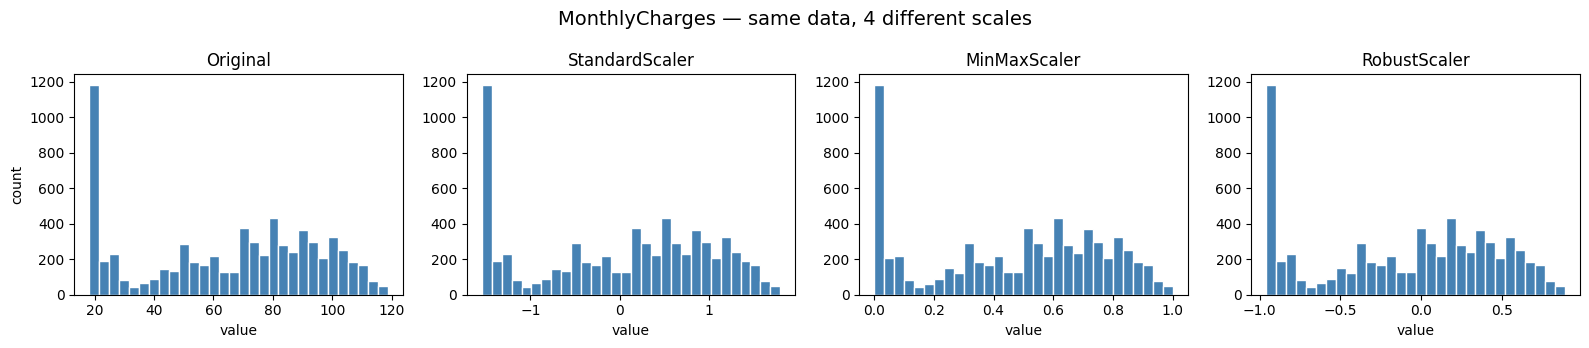


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👉 What you see in each chart:

  1. Original       → x-axis: 18 to 118 (real dollars)
  2. StandardScaler → x-axis: ~-2 to ~2 (mean=0, std=1)
  3. MinMaxScaler   → x-axis: 0 to 1   (squeezed)
  4. RobustScaler   → x-axis: ~-1 to ~1 (centered on median)

💡 The SHAPE is the same — only the SIZE changes!
   Scaling does not change the data. It changes the scale.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [11]:
# Visual comparison: histogram of MonthlyCharges with each scaler
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))

data_views = [
    ('Original',       df['MonthlyCharges']),
    ('StandardScaler', X_standard_df['MonthlyCharges']),
    ('MinMaxScaler',   X_minmax_df['MonthlyCharges']),
    ('RobustScaler',   pd.DataFrame(RobustScaler().fit_transform(X), columns=cols)['MonthlyCharges'])
]

for i, (name, data) in enumerate(data_views):
    ax[i].hist(data, bins=30, color='steelblue', edgecolor='white')
    ax[i].set_title(name)
    ax[i].set_xlabel('value')
    if i == 0: ax[i].set_ylabel('count')

plt.suptitle('MonthlyCharges — same data, 4 different scales', fontsize=14)
plt.tight_layout()
plt.show()

print()
print('━' * 50)
print('👉 What you see in each chart:')
print()
print('  1. Original       → x-axis: 18 to 118 (real dollars)')
print('  2. StandardScaler → x-axis: ~-2 to ~2 (mean=0, std=1)')
print('  3. MinMaxScaler   → x-axis: 0 to 1   (squeezed)')
print('  4. RobustScaler   → x-axis: ~-1 to ~1 (centered on median)')
print()
print('💡 The SHAPE is the same — only the SIZE changes!')
print('   Scaling does not change the data. It changes the scale.')
print('━' * 50)

---

## 🎁 Bonus — are these the ONLY scalers?

We learned **3** today: StandardScaler, MinMaxScaler, RobustScaler.

These are the **3 most popular**. But sklearn has more! Here's a fuller picture:

| Scaler | What it does | When to use |
| --- | --- | --- |
| **StandardScaler** ⭐ | mean=0, std=1 | **Default. Use this 80% of the time.** |
| **MinMaxScaler** | squeeze to [0, 1] | When the model needs values in [0,1] (neural nets, images) |
| **RobustScaler** 🛡️ | uses median + IQR | When data has wild outliers |
| **MaxAbsScaler** | divide by biggest absolute value | When data is sparse (lots of zeros) |
| **Normalizer** | makes each ROW sum to 1 | Text/document data — note: works on rows, not columns |
| **PowerTransformer** | makes data look like a bell curve | When data is very skewed |
| **QuantileTransformer** | maps to a normal distribution | Strong fix for weird-shaped data |

### 💡 You don't need to memorize all 7

**The simple rule of thumb:**

1. **First try:** `StandardScaler` ← works for ~80% of cases
2. If outliers exist → switch to `RobustScaler`
3. If model needs [0, 1] → switch to `MinMaxScaler`
4. The other 4? You'll meet them later when you actually need them.

### 🌍 In real ML jobs

- **StandardScaler** is the most common. **Memorize this one first.**
- **MinMaxScaler** for neural networks / image data (pixel values 0-255 → 0-1).
- **RobustScaler** for finance / banking / fraud / telecom — these fields ALWAYS have outliers.

These 3 cover 99% of real work. ✅

---
## Step 7: 🚨 The BIG RULE — fit on TRAIN data only

This is the **most important rule** of the whole module. Listen carefully.

### What is train/test split?

Before training a model, we split the data into 2 parts:
- **Train data** (~80%) — the model learns from this
- **Test data** (~20%) — we keep it secret to check the model later

Like an exam:
- Train data = practice questions
- Test data = the real exam (model has never seen it)

### What is data leakage?

**Data leakage = information from test data secretly leaks into training.**

Imagine you are a teacher. You give Ali the exam answers BEFORE the exam. Ali gets 100%. But Ali doesn't know math!

Same with our model. If the scaler "sees" the test data, the model is **cheating**. It looks great on the test but fails in real life (production).

### The wrong way ❌

```python
# WRONG! Scaler sees ALL data including test
X_scaled = scaler.fit_transform(X)
X_train, X_test = train_test_split(X_scaled)
```

### The right way ✅

```python
# Split FIRST
X_train, X_test = train_test_split(X)

# Scaler learns from train ONLY
X_train_scaled = scaler.fit_transform(X_train)

# Same scaler is applied to test (no learning, just apply)
X_test_scaled = scaler.transform(X_test)
```

### Why this matters in production

In real life, when a NEW customer arrives, you don't know their data yet. You have to scale them using the **old** scaler from training. So that's exactly how we should test the model — apply the train scaler to test data.

**Memorize:** *fit_transform on TRAIN, transform on TEST. Never both.*

In [12]:
# Show the right way in code
y = (df['Churn'] == 'Yes').astype(int)  # target column (1 = left, 0 = stayed)

# STEP 1: split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# STEP 2: fit scaler on train ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# STEP 3: apply same scaler to test (no fit!)
X_test_scaled = scaler.transform(X_test)

print('✅ The right way!')
print(f'   Train rows: {len(X_train)}')
print(f'   Test rows : {len(X_test)}')
print()
print('   Train MonthlyCharges:')
print(f'     Before scaling: mean = {X_train["MonthlyCharges"].mean():.2f}')
print(f'     After scaling : mean = {X_train_scaled[:, 1].mean():.2f}  (should be ~0)')
print()
print('💡 The scaler ONLY saw training data when learning.')
print('   Test data was scaled using the same numbers, but never used for learning.')

✅ The right way!
   Train rows: 5634
   Test rows : 1409

   Train MonthlyCharges:
     Before scaling: mean = 64.86
     After scaling : mean = -0.00  (should be ~0)

💡 The scaler ONLY saw training data when learning.
   Test data was scaled using the same numbers, but never used for learning.


---
## Step 8: Hands-on — which scaler wins on a real model? 🎯

Let's train a **K-Nearest Neighbors (KNN)** model to predict churn.

**KNN** = a model that finds the K closest customers to predict. Closest = uses **distance**. So it CARES about scaling a lot.

We'll try 4 versions:
- No scaling
- StandardScaler
- MinMaxScaler
- RobustScaler

Which one will give the best accuracy?

In [13]:
# Test all 4 versions
scalers = {
    'No scaling':     None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler()
}

print('🏁 Training KNN with each scaler...\n')

results = {}
for name, scaler in scalers.items():
    if scaler is None:
        Xtr, Xte = X_train.values, X_test.values
    else:
        Xtr = scaler.fit_transform(X_train)   # fit on train only!
        Xte = scaler.transform(X_test)         # transform test only

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(Xtr, y_train)
    acc = accuracy_score(y_test, knn.predict(Xte))
    results[name] = acc
    print(f'   {name:18s} → {acc*100:.2f}% accuracy')

print()
print('━' * 50)
best = max(results, key=results.get)
worst = min(results, key=results.get)
diff = (results[best] - results[worst]) * 100
print(f'🏆 BEST : {best} ({results[best]*100:.2f}%)')
print(f'😢 WORST: {worst} ({results[worst]*100:.2f}%)')
print(f'   Difference: {diff:.1f} percentage points')
print()
print('💡 Scaling really matters for distance-based models like KNN!')
print('━' * 50)

🏁 Training KNN with each scaler...

   No scaling         → 77.93% accuracy
   StandardScaler     → 78.85% accuracy
   MinMaxScaler       → 78.64% accuracy
   RobustScaler       → 79.06% accuracy

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 BEST : RobustScaler (79.06%)
😢 WORST: No scaling (77.93%)
   Difference: 1.1 percentage points

💡 Scaling really matters for distance-based models like KNN!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 🤔 Stop and think

1. By how much did the BEST scaler beat the WORST?
2. Why did `No scaling` fail badly?
3. Imagine 1000 customers and 10% accuracy difference. How many predictions are now correct that were wrong before?

---
## Step 9: Save the scaled data 💾

We will use this cleaned + scaled data in **Class 3** (feature engineering).

We pick the scaler that worked best (or most popular: StandardScaler) and save the result.

In [14]:
# Save the scaled training data + the scaler itself
import joblib

# Save the scaled features as CSV
out = pd.DataFrame(X_train_scaled, columns=cols)
out['Churn'] = y_train.values
out.to_csv('telco_scaled.csv', index=False)

# Save the SCALER OBJECT itself (so we can apply it to new data later)
joblib.dump(scaler, 'scaler.joblib')

print('✅ Saved 2 files:')
print('   • telco_scaled.csv  → scaled data for Class 3')
print('   • scaler.joblib     → the scaler object (load it next class)')
print()
print('💡 Why save the scaler too?')
print('   When a NEW customer arrives in production, we need to scale them')
print('   using the SAME scaler from training. We can not re-fit it!')

✅ Saved 2 files:
   • telco_scaled.csv  → scaled data for Class 3
   • scaler.joblib     → the scaler object (load it next class)

💡 Why save the scaler too?
   When a NEW customer arrives in production, we need to scale them
   using the SAME scaler from training. We can not re-fit it!


---
## 🏁 We did it!

### Today's summary

| Topic | What we learned | Tool |
| --- | --- | --- |
| Why scale? | Different sizes confuse the model | — |
| Tool 1 | Mean=0, Std=1. Best default. | `StandardScaler` |
| Tool 2 | Squeeze to [0, 1]. Risky with outliers. | `MinMaxScaler` |
| Tool 3 | Uses median + IQR. Best with outliers. | `RobustScaler` |
| The big rule | Fit on TRAIN only. Transform TEST. | `train_test_split` |
| Real test | KNN improved a lot with scaling | `accuracy_score` |

### 🎓 Words to remember

- **scaling** — make all numbers fit in a similar range
- **standardization** — mean=0, std=1 (StandardScaler)
- **normalization** — squeeze to [0, 1] (MinMaxScaler)
- **mean** — average
- **std** — standard deviation = how spread out
- **median** — middle value
- **IQR** — middle 50% range (Q3 − Q1)
- **train/test split** — split data into learning set + check set
- **data leakage** — secret info from test sneaks into train (bad!)
- **KNN** — K-Nearest Neighbors, a distance-based model
- **accuracy** — % of correct predictions

### 🎯 Where we're going

- ✅ Class 1: Clean data
- ✅ Class 2: Scale numbers (today!)
- 📅 Class 3: **Categorical encoding** — turn text categories (`Yes/No`, city names) into numbers
- 📅 Class 4: Feature engineering — build NEW useful columns
- 📅 Module 4: Train the model. Predict who will leave!

### 📤 Submit

1. Save as `Module3_Class2_<YourName>.ipynb`
2. PR to your group repo at `module-3/class_2/submissions/<YourName>/`

📐 *Great work! See you in Class 3 — encoding text!*